In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

In [ ]:
# Import Quick,Draw! dataset for training
categories = ['book', 'car', 'crown', 'flamingo', 'moon', 'rabbit', 'submarine', 'watermelon']
all_train_drawings = []
all_inx = []

for inx_cat, category in enumerate(categories):
  data = np.load(f'data/sketchrnn_{category}.npz', allow_pickle=True, encoding='latin1')
  # 'train' is a tag of google dataset
  train_drawings = data['train'][:5000]
  # We insert every elemente of the array with .extend
  # (.append inserts all the array)
  all_train_drawings.extend(train_drawings)
  all_inx.extend([inx_cat] * len(train_drawings))

# Convert every drawing to tensor
tensor_list = []
lengths = []
for drawing in all_train_drawings:
  t = torch.tensor(drawing, dtype=torch.float32)
  tensor_list.append(t)
  lengths.append(len(t))

# Equal sizes
train_tensor = pad_sequence(tensor_list, batch_first=True)
# Normalize dx, dy
train_tensor[:, :, :2] = train_tensor[:, :, :2] / 100.0

inx_tensor = torch.tensor(all_inx, dtype=torch.long)
lengths_tensor = torch.tensor(lengths, dtype=torch.long)
# Create dataset
dataset = TensorDataset(train_tensor, lengths_tensor, inx_tensor)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [ ]:
# Create template of network
# output_size = 1, one word
class RNNModule(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)

    self.final = nn.Sequential(
      nn.Linear(hidden_size, 8),
      # No f.act, we use crossEntropyLoss (applies Softmax)
      nn.Linear(8, output_size),
    )

  def forward(self, x, lengths):
    packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
    packed_out, h_n = self.rnn(packed)
    # h_n is the last state
    last_output = h_n[-1] # form: (batch, hidden_size)
    return self.final(last_output)

In [ ]:
# input_size = [x, y]
# output_size = number of neurons in the final layer, number of categories
model = RNNModule(input_size=3, hidden_size=128, output_size=8)

# Loss function
f_loss = nn.CrossEntropyLoss()
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train(model, x, lengths, y, f_loss, optimizer):
  # Forward pass
  out = model(x, lengths)
  # Backward pass
  error = f_loss(out, y)
  optimizer.zero_grad()
  error.backward()
  optimizer.step()
  return error.item()

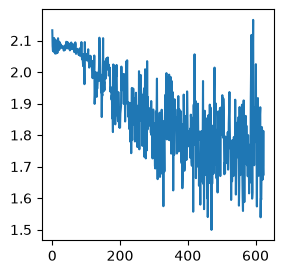

KeyboardInterrupt: 

In [ ]:
# Train model
loss_history = []
for epoch in range(200):
  for batch_x, batch_lengths, batch_y in loader:
    error = train(model, batch_x, batch_lengths, batch_y, f_loss, optimizer)
    loss_history.append(error)

    if epoch % 100 == 0:
      with torch.no_grad():
        clear_output(wait=True)
        # Print trainig
        plt.figure(figsize=(3,3))
        plt.plot(range(len(loss_history)), loss_history)
        plt.show()  

torch.save(model.state_dict(), 'model_trained.pth')


